# EDA 04 — Model Diagnostics

> **Read-only EDA.** This notebook visualises model performance on the OOT test set.
> It does NOT train, evaluate, or save anything — run `python -m ml.train` and
> `python -m ml.evaluate` first.

**Prerequisites**
```bash
python -m etl.run_pipeline --start 2005-01-01 --end 2024-12-31
python -m ml.train
python -m ml.evaluate
```

**Sections**
1. Setup
2. Error distributions
3. Residual analysis (bias, heteroscedasticity, autocorrelation)
4. Performance by price regime (floor / normal / spike)
5. Horizon degradation vs. naive baseline
6. Actual vs. predicted — all subsystems

In [1]:
import json
import sys
from pathlib import Path

import duckdb
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from ml.train import FEATURE_COLS, TARGET_COLS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

SUBSYSTEMS = ["SE/CO", "S", "NE", "N"]
COLORS = {"SE/CO": "#1f77b4", "S": "#2ca02c", "NE": "#ff7f0e", "N": "#9467bd"}

## 1. Setup

In [2]:
model_path   = ROOT / "models" / "lgbm_multioutput.pkl"
metrics_path = ROOT / "models" / "metrics.json"
test_path    = ROOT / "data" / "gold" / "abt_test.parquet"

for p in [model_path, test_path]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found — run ml/train.py first")

model  = joblib.load(model_path)
con    = duckdb.connect()
test   = con.execute(f"SELECT * FROM read_parquet('{test_path}')").fetchdf()
con.close()

test["week_start"] = pd.to_datetime(test["week_start"])
test = test.dropna(subset=FEATURE_COLS + TARGET_COLS).reset_index(drop=True)

X_test = test[FEATURE_COLS]
Y_test = test[TARGET_COLS]
Y_pred = pd.DataFrame(model.predict(X_test), columns=TARGET_COLS, index=test.index)

print(f"Test rows: {len(test)}  ({test['week_start'].min().date()} → {test['week_start'].max().date()})")

if metrics_path.exists():
    saved = json.loads(metrics_path.read_text())
    print("\nSaved metrics (from ml/evaluate.py):")
    for k, v in sorted(saved.items()):
        if isinstance(v, float):
            print(f"  {k}: {v:.3f}")

Test rows: 192  (2024-01-05 → 2024-11-29)

Saved metrics (from ml/evaluate.py):
  mae_mean_all: 75.302
  mae_n_mean: 72.344
  mae_n_t_plus_1w: 49.791
  mae_n_t_plus_2w: 59.541
  mae_n_t_plus_3w: 73.449
  mae_n_t_plus_4w: 106.596
  mae_ne_mean: 73.543
  mae_ne_t_plus_1w: 49.068
  mae_ne_t_plus_2w: 64.431
  mae_ne_t_plus_3w: 73.724
  mae_ne_t_plus_4w: 106.950
  mae_s_mean: 75.190
  mae_s_t_plus_1w: 50.734
  mae_s_t_plus_2w: 65.897
  mae_s_t_plus_3w: 76.050
  mae_s_t_plus_4w: 108.077
  mae_seco_mean: 80.133
  mae_seco_t_plus_1w: 53.617
  mae_seco_t_plus_2w: 70.015
  mae_seco_t_plus_3w: 85.537
  mae_seco_t_plus_4w: 111.363
  mae_t_plus_1w: 50.803
  mae_t_plus_2w: 64.971
  mae_t_plus_3w: 77.190
  mae_t_plus_4w: 108.246
  mape_mean_all: 586.469
  mape_t_plus_1w: 419.770
  mape_t_plus_2w: 598.491
  mape_t_plus_3w: 545.619
  mape_t_plus_4w: 781.994


## 2. Error Distributions

Positive error = model under-predicts; negative = over-predicts.

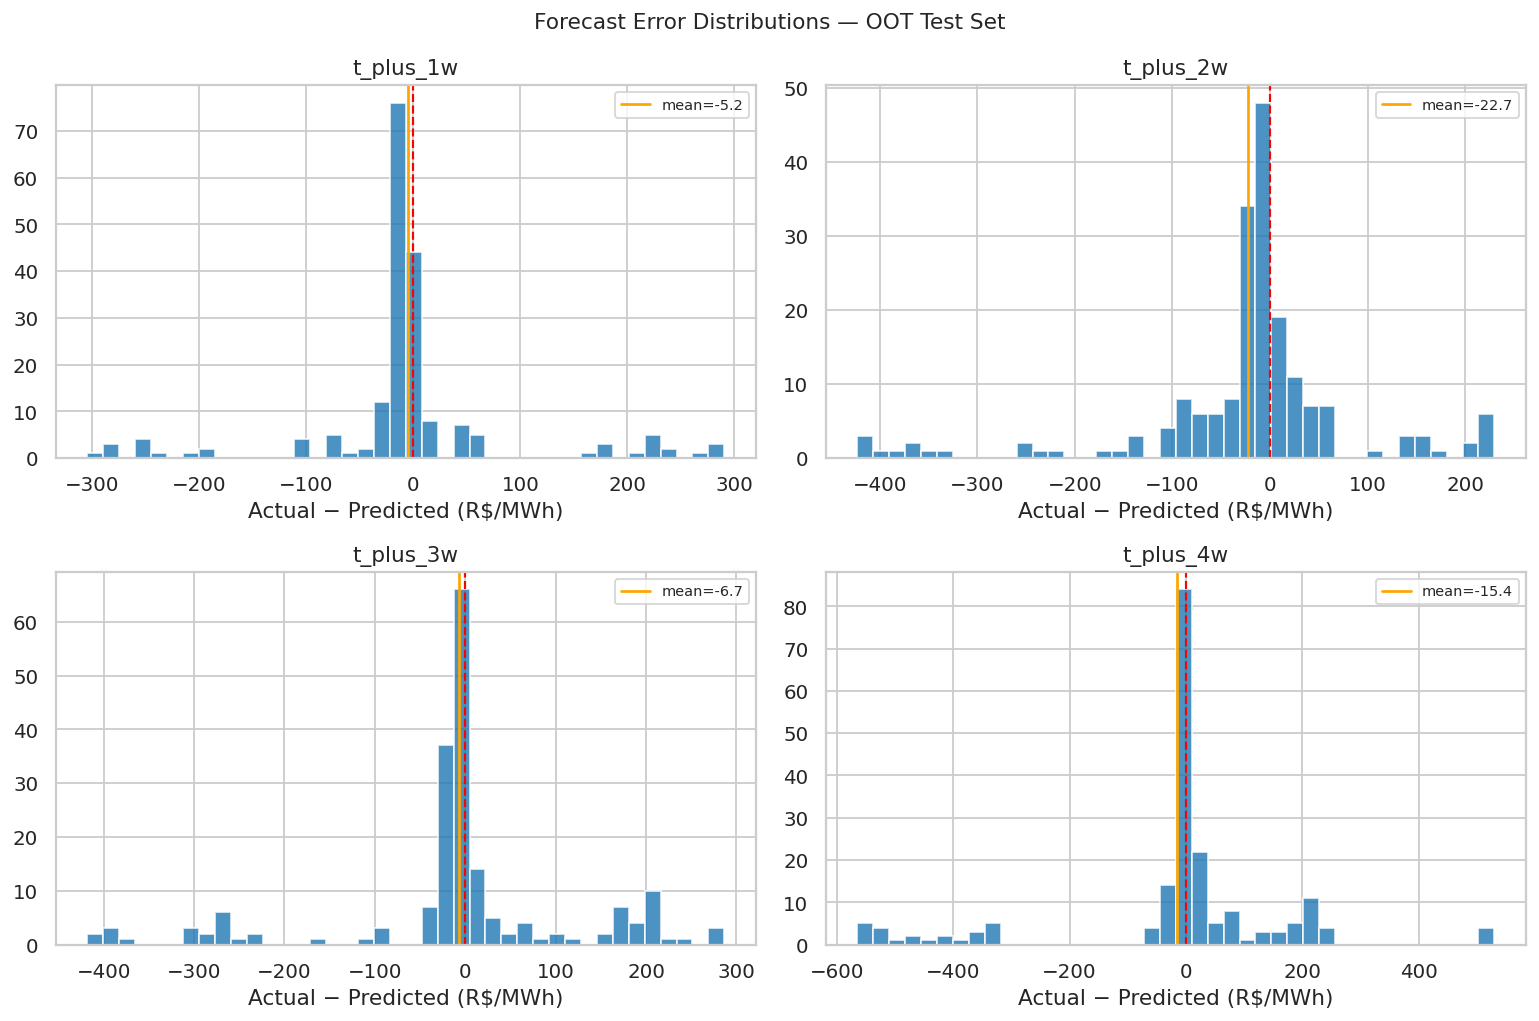

Error statistics:
  pld_t_plus_1w: mean=-5.15  std=95.22  median=-9.29
  pld_t_plus_2w: mean=-22.71  std=110.81  median=-11.40
  pld_t_plus_3w: mean=-6.72  std=131.27  median=-5.83
  pld_t_plus_4w: mean=-15.43  std=193.58  median=-2.48


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(TARGET_COLS):
    errors = Y_test[col].values - Y_pred[col].values
    axes[i].hist(errors, bins=40, edgecolor="white", alpha=0.8, color=COLORS["SE/CO"])
    axes[i].axvline(0, color="red", linestyle="--", linewidth=1.2)
    axes[i].axvline(errors.mean(), color="orange", linestyle="-",
                    label=f"mean={errors.mean():.1f}")
    axes[i].set_title(f"{col.replace('pld_', '')}")
    axes[i].set_xlabel("Actual − Predicted (R$/MWh)")
    axes[i].legend(fontsize=8)

plt.suptitle("Forecast Error Distributions — OOT Test Set", fontsize=12)
plt.tight_layout()
plt.show()

print("Error statistics:")
for col in TARGET_COLS:
    e = Y_test[col].values - Y_pred[col].values
    print(f"  {col}: mean={e.mean():+.2f}  std={e.std():.2f}  median={np.median(e):+.2f}")

## 3. Residual Analysis

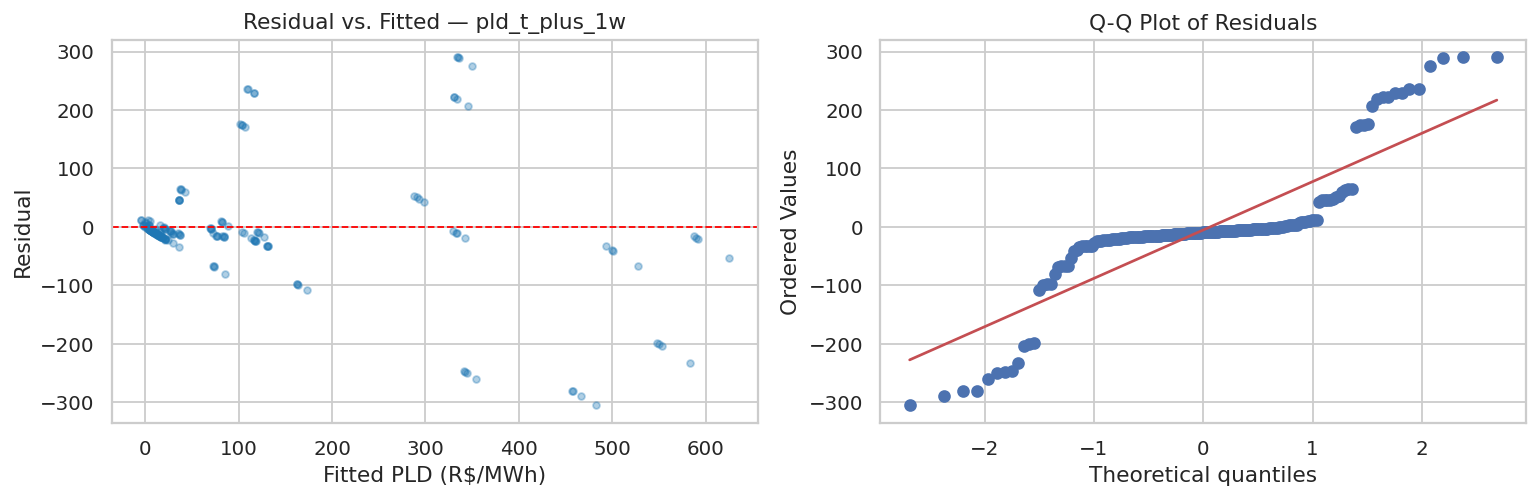

In [4]:
# Residual vs. fitted — check for heteroscedasticity (larger errors at high prices)
col = TARGET_COLS[0]
residuals = Y_test[col].values - Y_pred[col].values
fitted    = Y_pred[col].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted, residuals, alpha=0.35, s=14, color=COLORS["SE/CO"])
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted PLD (R$/MWh)")
axes[0].set_ylabel("Residual")
axes[0].set_title(f"Residual vs. Fitted — {col}")

stats.probplot(residuals, plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

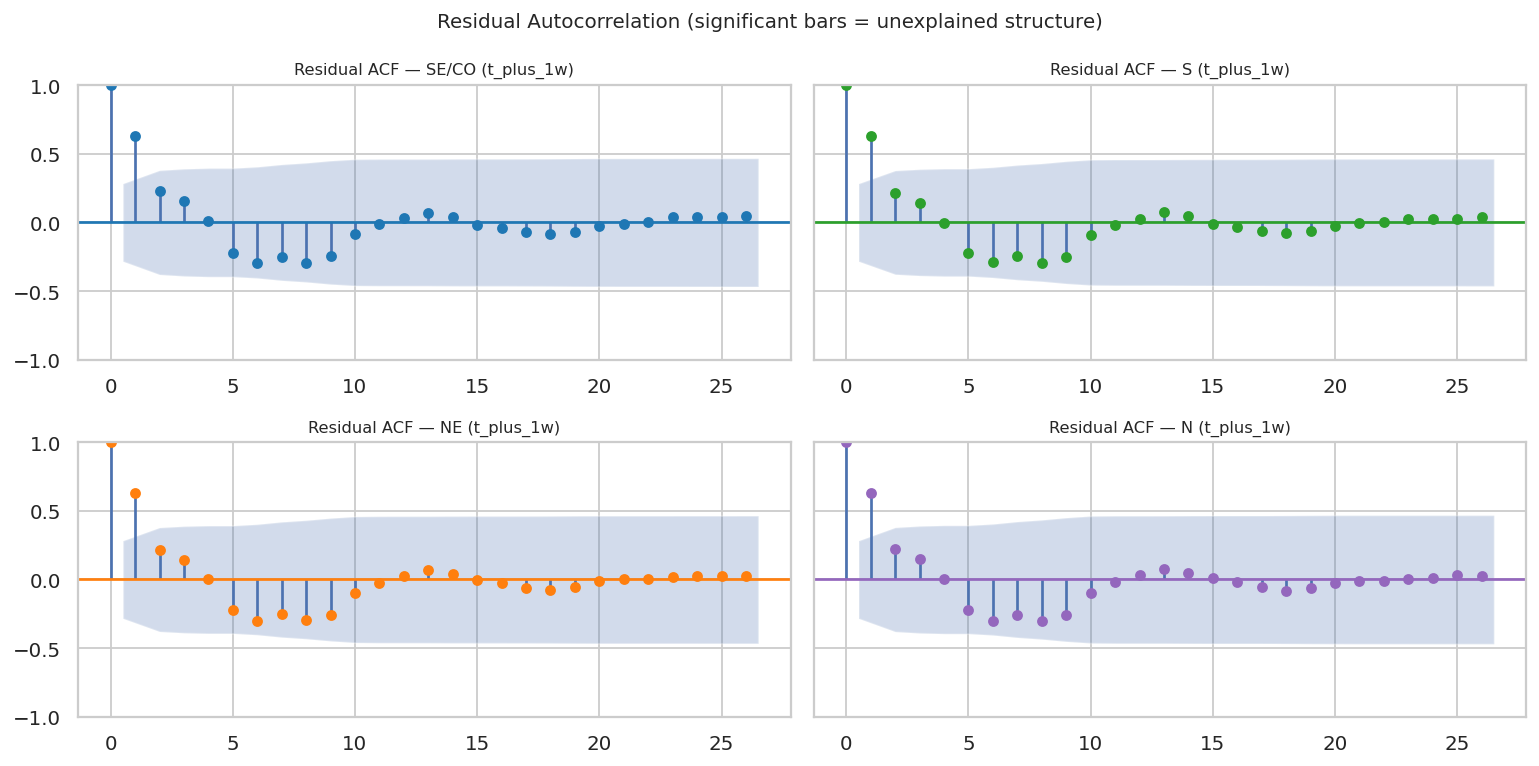

In [5]:
# Residual autocorrelation — significant ACF = model is leaving predictable structure
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=True)
axes = axes.flatten()

for ax, sub in zip(axes, SUBSYSTEMS):
    mask = test["subsystem"] == sub
    res = (
        Y_test.loc[mask, TARGET_COLS[0]].values -
        Y_pred.loc[mask, TARGET_COLS[0]].values
    )
    if len(res) > 10:
        plot_acf(res, lags=min(26, len(res) - 1), ax=ax, color=COLORS[sub])
    ax.set_title(f"Residual ACF — {sub} ({TARGET_COLS[0].replace('pld_', '')})", fontsize=9)

plt.suptitle("Residual Autocorrelation (significant bars = unexplained structure)", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Performance by Price Regime

PLD is bounded (ANEEL floor/ceiling) and right-skewed. We expect the model to
struggle most at the extremes (near-floor and spike weeks).

In [6]:
col = TARGET_COLS[0]
p25 = Y_test[col].quantile(0.25)
p75 = Y_test[col].quantile(0.75)

regimes = {
    f"Near-floor (≤P25, ≤{p25:.0f})": Y_test[col] <= p25,
    f"Mid-range (P25–P75)": (Y_test[col] > p25) & (Y_test[col] < p75),
    f"Spike (≥P75, ≥{p75:.0f})": Y_test[col] >= p75,
}

print(f"Performance on {col} by price regime:\n")
for label, mask in regimes.items():
    n = mask.sum()
    if n == 0:
        continue
    mae  = mean_absolute_error(Y_test.loc[mask, col], Y_pred.loc[mask, col])
    mape = mean_absolute_percentage_error(Y_test.loc[mask, col], Y_pred.loc[mask, col]) * 100
    print(f"  {label:38s}: n={n:3d}, MAE={mae:.1f} R$/MWh, MAPE={mape:.1f}%")

Performance on pld_t_plus_1w by price regime:

  Near-floor (≤P25, ≤0)                 : n= 48, MAE=10.8 R$/MWh, MAPE=4137118996383837696.0%
  Mid-range (P25–P75)                   : n= 96, MAE=29.0 R$/MWh, MAPE=1339.9%
  Spike (≥P75, ≥99)                     : n= 48, MAE=134.5 R$/MWh, MAPE=45.1%


## 5. Horizon Degradation vs. Naive Baseline

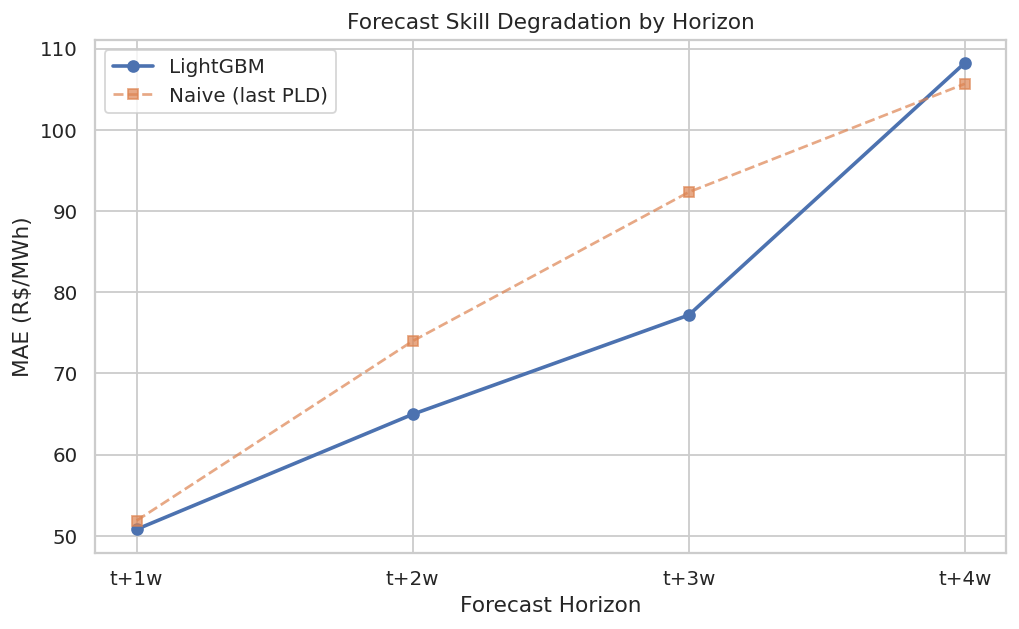

Skill score vs. naive (positive = beats naive):
  t+1w: MAE=50.8, naive=51.9, skill=+2.1%
  t+2w: MAE=65.0, naive=74.0, skill=+12.2%
  t+3w: MAE=77.2, naive=92.3, skill=+16.4%
  t+4w: MAE=108.2, naive=105.7, skill=-2.4%


In [7]:
horizons_label = ["t+1w", "t+2w", "t+3w", "t+4w"]
mae_model = [mean_absolute_error(Y_test[col], Y_pred[col]) for col in TARGET_COLS]
mae_naive = [mean_absolute_error(Y_test[col], test["pld_lag_1w"]) for col in TARGET_COLS]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(horizons_label, mae_model, marker="o", linewidth=2, label="LightGBM")
ax.plot(horizons_label, mae_naive, marker="s", linestyle="--", alpha=0.7, label="Naive (last PLD)")
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("MAE (R$/MWh)")
ax.set_title("Forecast Skill Degradation by Horizon")
ax.legend()
plt.tight_layout()
plt.show()

print("Skill score vs. naive (positive = beats naive):")
for h, m, n in zip(horizons_label, mae_model, mae_naive):
    skill = (n - m) / n * 100
    print(f"  {h}: MAE={m:.1f}, naive={n:.1f}, skill={skill:+.1f}%")

## 6. Actual vs. Predicted — All Subsystems

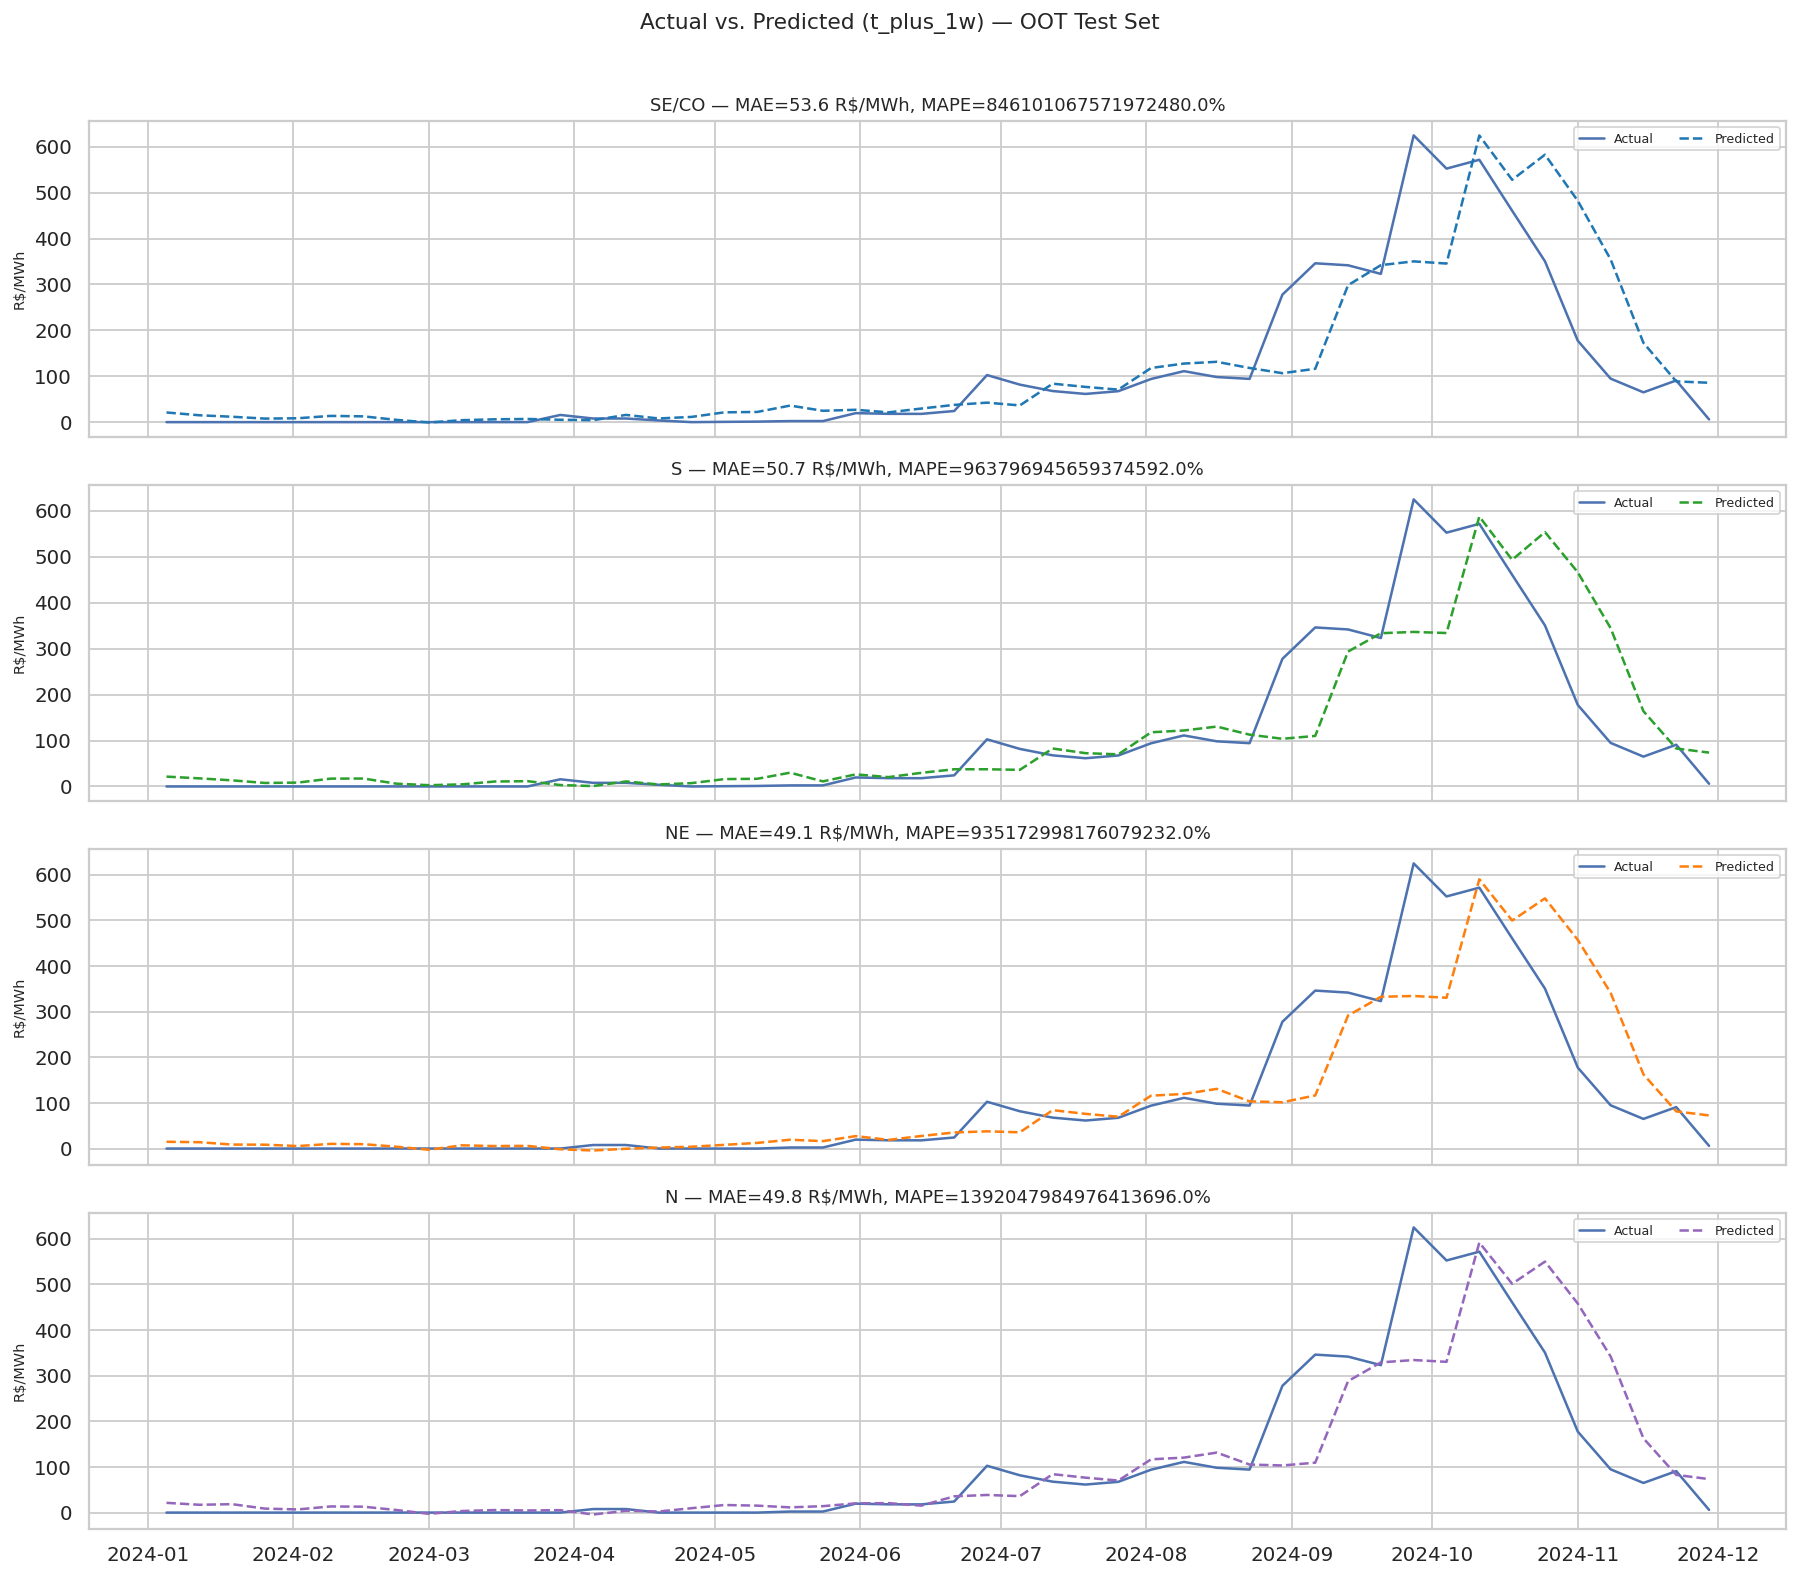

In [8]:
col = TARGET_COLS[0]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

for ax, sub in zip(axes, SUBSYSTEMS):
    mask = test["subsystem"] == sub
    t    = test.loc[mask, "week_start"]
    ax.plot(t, Y_test.loc[mask, col], label="Actual", linewidth=1.4)
    ax.plot(t, Y_pred.loc[mask, col], label="Predicted",
            linewidth=1.4, linestyle="--", color=COLORS[sub])
    mae  = mean_absolute_error(Y_test.loc[mask, col], Y_pred.loc[mask, col])
    mape = mean_absolute_percentage_error(Y_test.loc[mask, col], Y_pred.loc[mask, col]) * 100
    ax.set_title(f"{sub} — MAE={mae:.1f} R$/MWh, MAPE={mape:.1f}%", fontsize=10)
    ax.set_ylabel("R$/MWh", fontsize=8)
    ax.legend(fontsize=7, ncol=2)

plt.suptitle(
    f"Actual vs. Predicted ({col.replace('pld_', '')}) — OOT Test Set",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

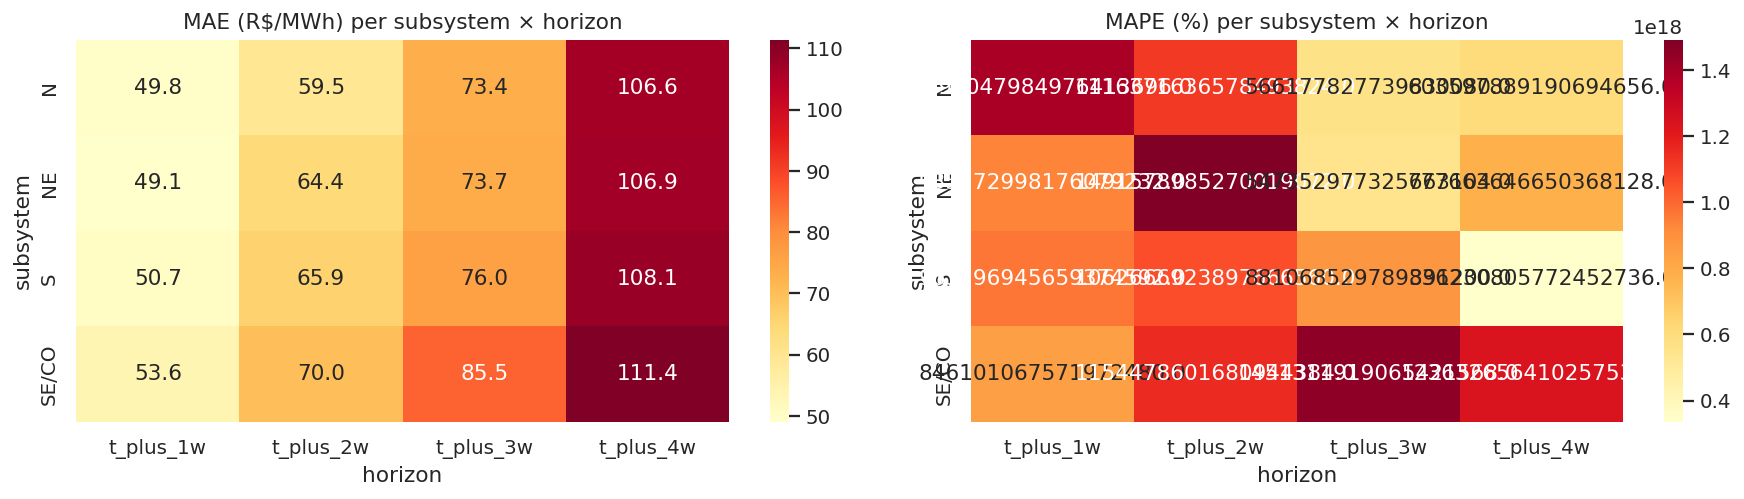

In [9]:
# Per-subsystem × horizon MAE heatmap
sub_metrics = []
for sub in SUBSYSTEMS:
    mask = test["subsystem"] == sub
    for col in TARGET_COLS:
        mae  = mean_absolute_error(Y_test.loc[mask, col], Y_pred.loc[mask, col])
        mape = mean_absolute_percentage_error(Y_test.loc[mask, col], Y_pred.loc[mask, col]) * 100
        sub_metrics.append({"subsystem": sub, "horizon": col.replace("pld_", ""), "MAE": mae, "MAPE_%": mape})

sub_df = pd.DataFrame(sub_metrics)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pivot_mae  = sub_df.pivot(index="subsystem", columns="horizon", values="MAE").round(1)
pivot_mape = sub_df.pivot(index="subsystem", columns="horizon", values="MAPE_%").round(1)

sns.heatmap(pivot_mae,  annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("MAE (R$/MWh) per subsystem × horizon")

sns.heatmap(pivot_mape, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("MAPE (%) per subsystem × horizon")

plt.tight_layout()
plt.show()

## 7. Feature Importances

LightGBM exposes `feature_importances_` (gain-based) for each of the 4 target estimators.
Gain importance = average improvement in split quality weighted by number of uses.

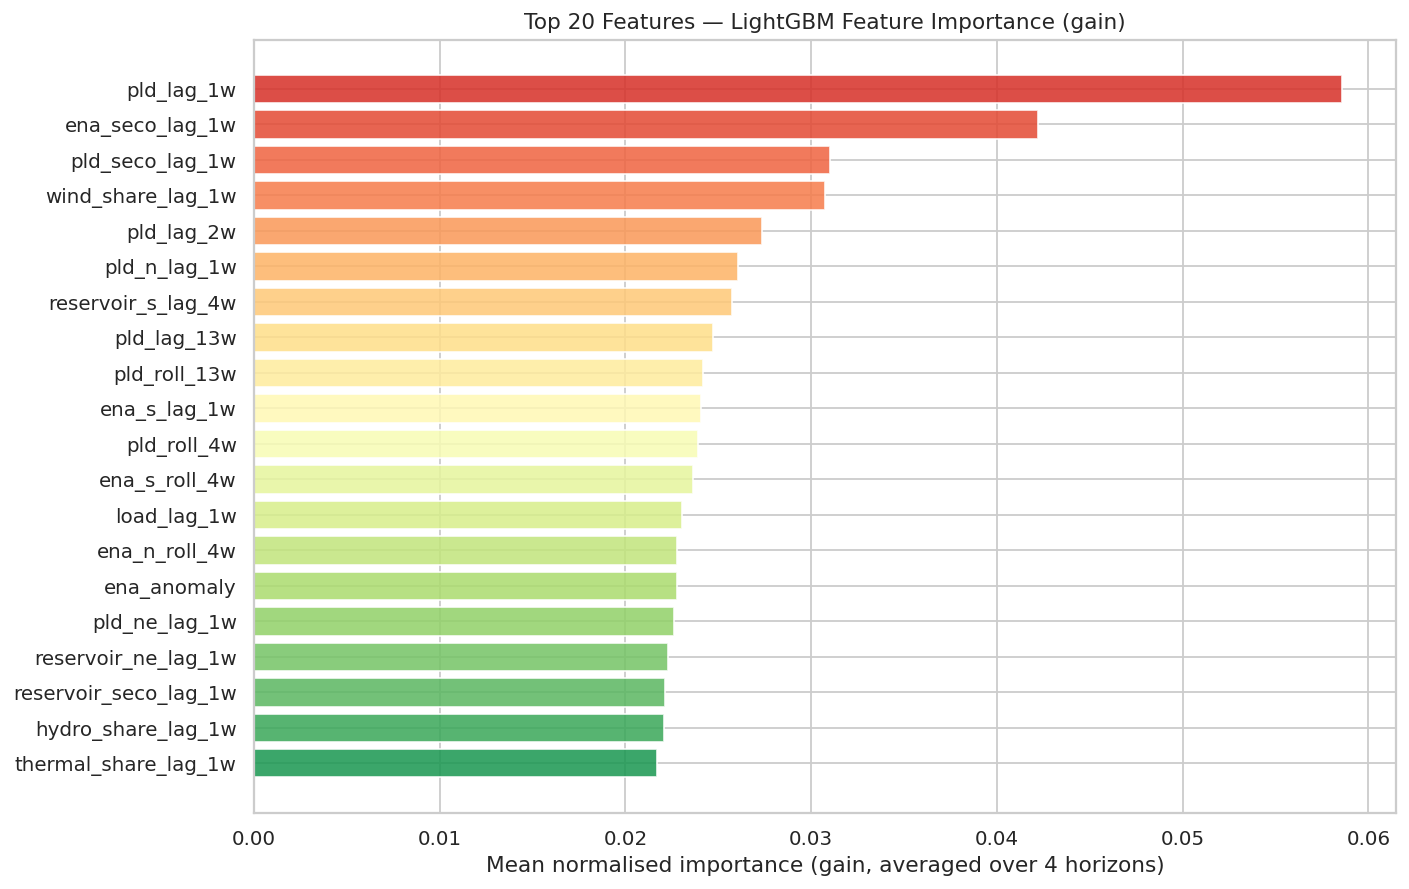

Top 20 features by mean gain importance:
  pld_lag_1w                         : 0.0586
  ena_seco_lag_1w                    : 0.0422
  pld_seco_lag_1w                    : 0.0310
  wind_share_lag_1w                  : 0.0308
  pld_lag_2w                         : 0.0274
  pld_n_lag_1w                       : 0.0261
  reservoir_s_lag_4w                 : 0.0257
  pld_lag_13w                        : 0.0247
  pld_roll_13w                       : 0.0242
  ena_s_lag_1w                       : 0.0240
  pld_roll_4w                        : 0.0239
  ena_s_roll_4w                      : 0.0236
  load_lag_1w                        : 0.0230
  ena_n_roll_4w                      : 0.0228
  ena_anomaly                        : 0.0228
  pld_ne_lag_1w                      : 0.0226
  reservoir_ne_lag_1w                : 0.0223
  reservoir_seco_lag_1w              : 0.0221
  hydro_share_lag_1w                 : 0.0221
  thermal_share_lag_1w               : 0.0217


In [10]:
# Extract feature importances from each LGBMRegressor in the MultiOutputRegressor
estimators = model.named_steps["model"].estimators_   # list of 4 LGBMRegressors
horizon_labels = ["t+1w", "t+2w", "t+3w", "t+4w"]

importance_df = pd.DataFrame(
    {h: est.feature_importances_ for h, est in zip(horizon_labels, estimators)},
    index=FEATURE_COLS
)

# Normalise each horizon to sum to 1 for comparability
importance_norm = importance_df.div(importance_df.sum(axis=0), axis=1)

# ── Top-20 features by mean importance across horizons ──────────────────────
mean_imp = importance_norm.mean(axis=1).sort_values(ascending=False)
top20 = mean_imp.head(20)

fig, ax = plt.subplots(figsize=(11, 7))
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 20))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors_bar, alpha=0.85)
ax.set_xlabel("Mean normalised importance (gain, averaged over 4 horizons)")
ax.set_title("Top 20 Features — LightGBM Feature Importance (gain)")
plt.tight_layout()
plt.show()

print("Top 20 features by mean gain importance:")
for feat, val in top20.items():
    print(f"  {feat:35s}: {val:.4f}")

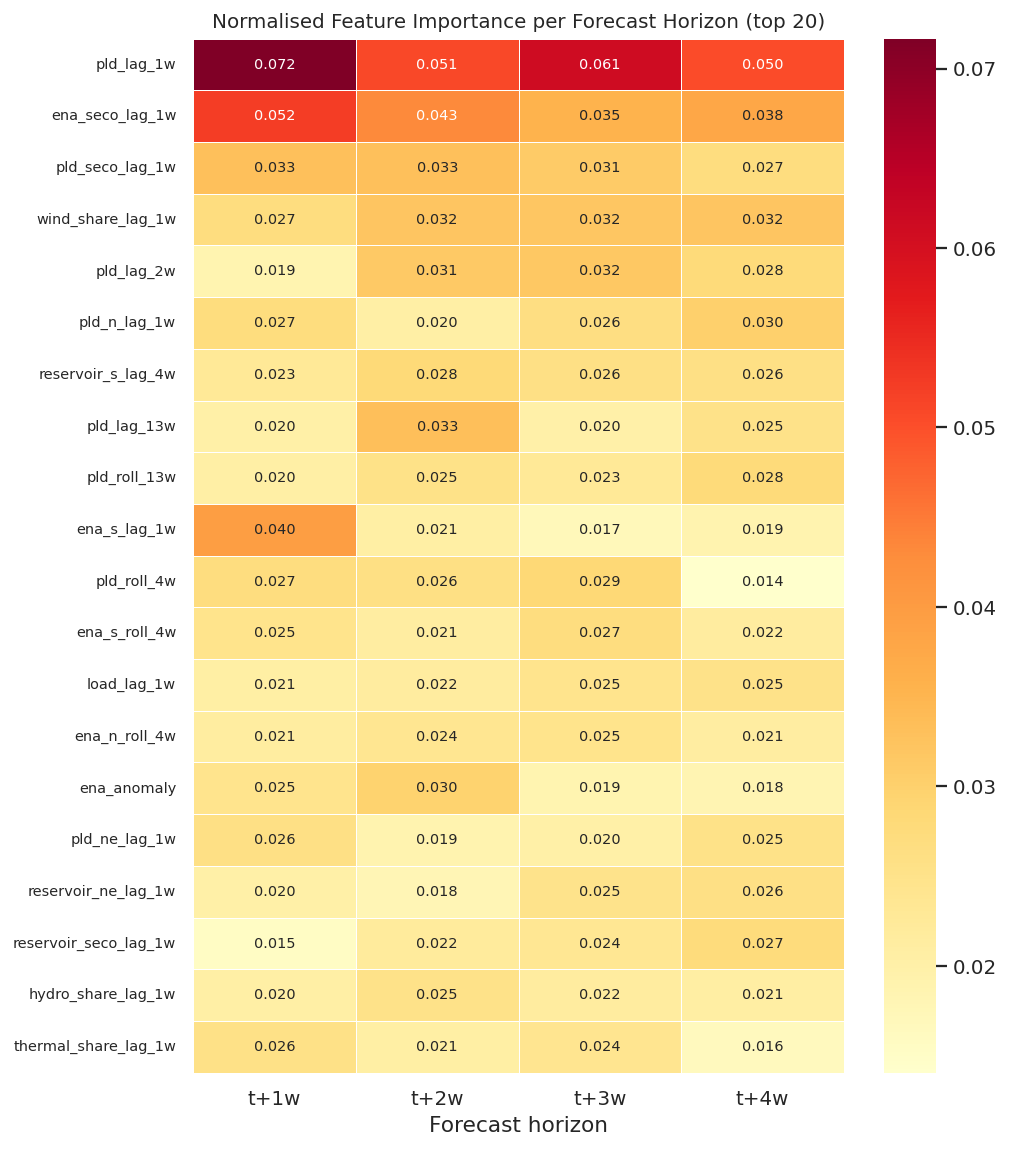

In [11]:
# ── Heatmap: top-20 features × 4 horizons ────────────────────────────────────
top20_norm = importance_norm.loc[top20.index]

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(
    top20_norm,
    annot=True, fmt=".3f", annot_kws={"size": 8},
    cmap="YlOrRd", linewidths=0.4, ax=ax
)
ax.set_title("Normalised Feature Importance per Forecast Horizon (top 20)", fontsize=11)
ax.set_xlabel("Forecast horizon")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

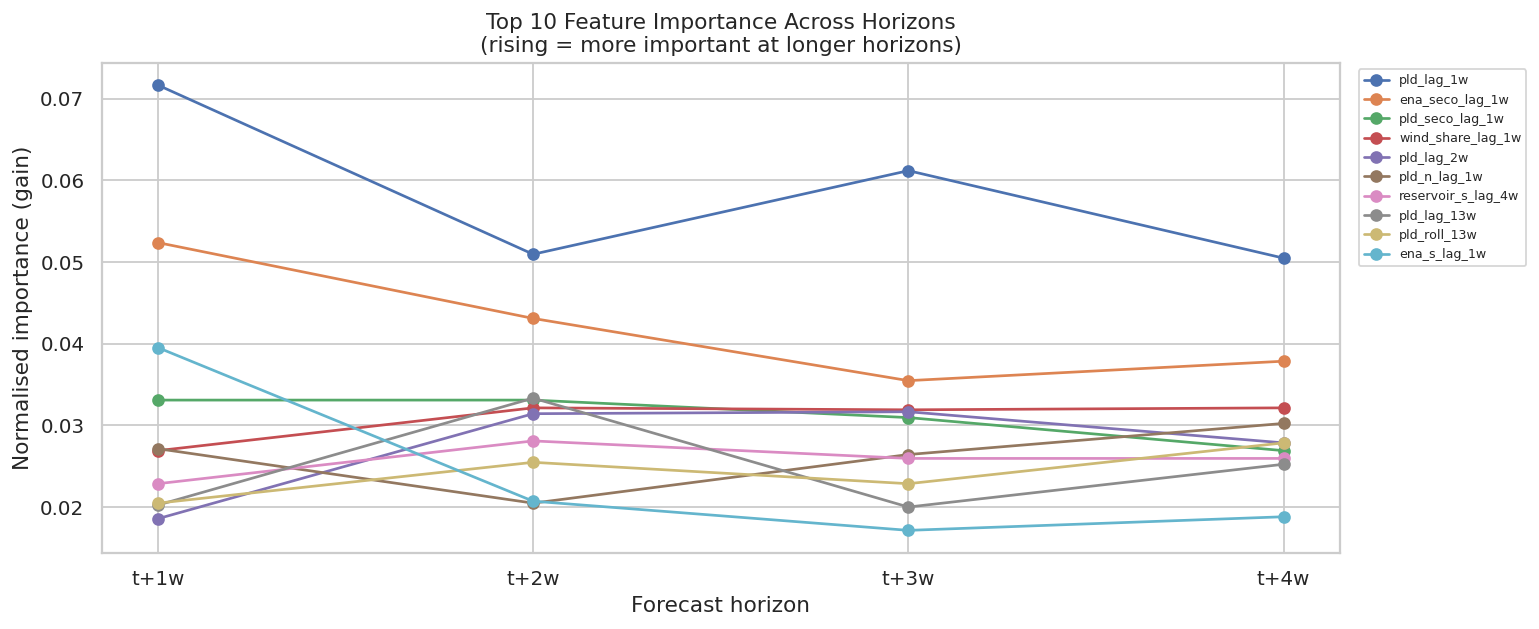

/tmp/ipykernel_175915/695400579.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(group_series.index, rotation=20, ha="right")


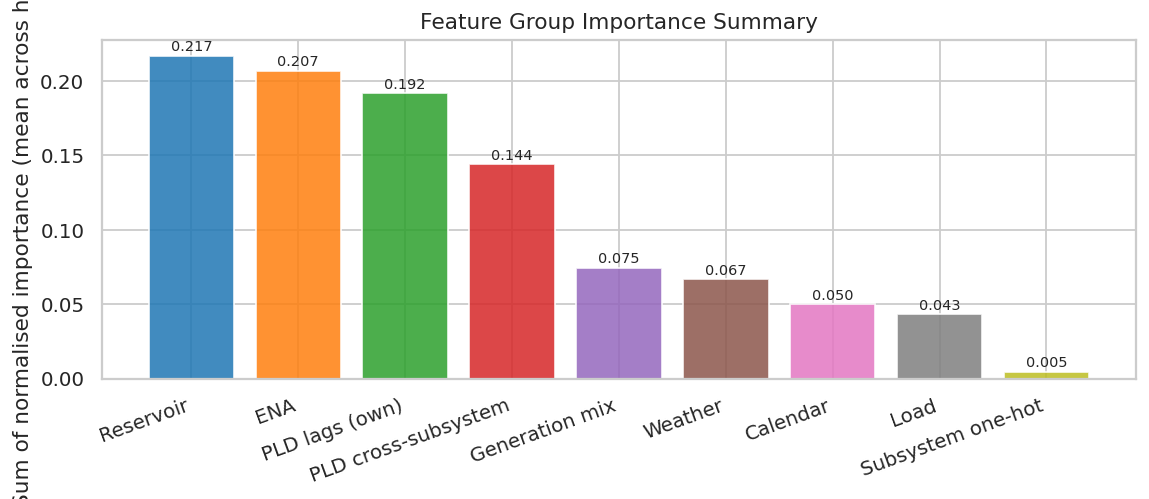

In [12]:
# ── Importance shift across horizons for the top 10 features ─────────────────
# Shows which features matter more at short vs. long horizons
top10 = mean_imp.head(10).index.tolist()
top10_df = importance_norm.loc[top10].T   # horizons as rows, features as columns

fig, ax = plt.subplots(figsize=(12, 5))
for feat in top10:
    ax.plot(horizon_labels, top10_df[feat].values, marker="o", linewidth=1.5, label=feat)

ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Normalised importance (gain)")
ax.set_title("Top 10 Feature Importance Across Horizons\n(rising = more important at longer horizons)")
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ── Feature group importance summary ─────────────────────────────────────────
groups = {
    "PLD lags (own)":      [f for f in FEATURE_COLS if f.startswith("pld_lag") or f.startswith("pld_roll")],
    "PLD cross-subsystem": [f for f in FEATURE_COLS if "pld_seco" in f or "pld_s_" in f or "pld_ne_" in f or "pld_n_" in f],
    "Reservoir":           [f for f in FEATURE_COLS if "reservoir" in f],
    "ENA":                 [f for f in FEATURE_COLS if "ena" in f],
    "Generation mix":      [f for f in FEATURE_COLS if "_share_" in f],
    "Load":                [f for f in FEATURE_COLS if "load" in f],
    "Weather":             [f for f in FEATURE_COLS if "precip" in f or "temp" in f],
    "Calendar":            [f for f in FEATURE_COLS if f in ("week_sin", "week_cos", "month_sin", "month_cos", "is_dry_season", "has_holiday_week", "year")],
    "Subsystem one-hot":   [f for f in FEATURE_COLS if f.startswith("is_") and f not in ("is_dry_season",)],
}

group_imp = {
    name: importance_norm.loc[feats].sum(axis=0).mean()
    for name, feats in groups.items()
    if feats
}
group_series = pd.Series(group_imp).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(group_series.index, group_series.values,
              color=plt.cm.tab10(np.arange(len(group_series))), alpha=0.85)
ax.set_ylabel("Sum of normalised importance (mean across horizons)")
ax.set_title("Feature Group Importance Summary")
ax.set_xticklabels(group_series.index, rotation=20, ha="right")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()